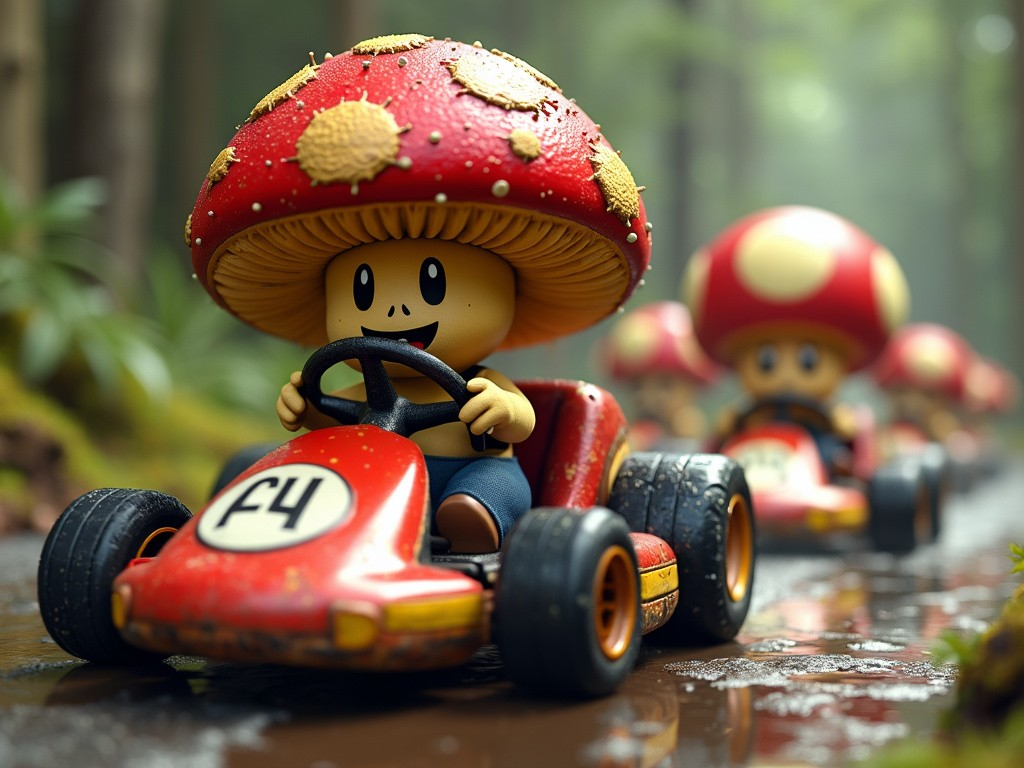

# 🤗 Simple tricks to iterate quickly

### 0. Run dataframes in the GPU with one line
*credit https://www.kaggle.com/cpmpml*
```python
%load_ext cudf.pandas
```

### 1. Are you sure your pipeline works?
I can't remember the number of times I thought my pipeline was fully working only to train 30 min and realized that I changed a variable name or whatever... so I always comment and uncomment this line just to see if the full pipeline is working. *caveat: don't do eda or features importance with this*
```python
df = df.sample(n=1000)  # Sample 1000 rows
```

### 2. Caching Preprocessed Data
Save your preprocessing to disk
```python
pipeline = make_pipeline(cont_cols, cat_cols=cat_cols)
train_x_preprocessed = pipeline.fit_transform(train_x)
val_x_preprocessed = pipeline.transform(val_x)
test_x_preprocessed = pipeline.transform(test_df[features])

np.save('train_x_preprocessed.npy', train_x_preprocessed)
np.save('train_y.npy', train_y)
```

And load it back! Without ever redoing the preprocessing again *(maybe)*:
```python
train_x_preprocessed = np.load('train_x_preprocessed.npy')
train_y = np.load('train_y.npy')
```

*caveat: for the final submission you will still have to rerun all the cells*

In [1]:
# %pip install \
#     --extra-index-url=https://pypi.nvidia.com \
#     cudf-cu12==24.6.* dask-cudf-cu12==24.6.* cuml-cu12==24.6.* \
#     cugraph-cu12==24.6.* cuspatial-cu12==24.6.* cuproj-cu12==24.6.* \
#     cuxfilter-cu12==24.6.* cucim-cu12==24.6.* pylibraft-cu12==24.6.* \
#     raft-dask-cu12==24.6.* cuvs-cu12==24.6.*

In [2]:
# %pip install kaggle pandas matplotlib seaborn scikit-learn category_encoders torchmetrics kagtool tqdm xgboost lightgbm catboost optuna fastai

# Preprocess

In [3]:
# needs a gpu accelerator
%load_ext cudf.pandas

In [4]:
# Standard library imports
import gc
import os
import time
from pathlib import Path

# Third-party library imports
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific and machine learning libraries
import category_encoders as ce
from category_encoders import TargetEncoder
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, matthews_corrcoef, roc_curve, precision_recall_curve, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)

# Gradient boosting libraries
import optuna
import xgboost as xgb
import lightgbm as lgbm
import catboost as cb

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchmetrics.classification import BinaryAUROC, BinaryMatthewsCorrCoef
from torchmetrics.functional import roc as torch_roc


sns.set_theme(style="whitegrid", palette="muted")
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 140)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


competition = 'playground-series-s4e8'
path = Path('/kaggle/input' if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ else '.')/competition

sample_df = pd.read_csv(path/'sample_submission.csv')
test_df = pd.read_csv(path/'test.csv')
df = pd.read_csv(path/'train.csv')

#DEBUG - Just checking to test run the pipeline
small_df = df.sample(n=1000)


# # Custom transformer for cleaning categorical data
class ArtifactCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols, replace_threshold=0.001):
        self.cat_cols = cat_cols
        self.replace_threshold = replace_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        for col in self.cat_cols:
            if df[col].dtype == "object":
                threshold_count = len(df[col]) * self.replace_threshold
                
                value_counts = df[col].value_counts()
                infrequent_values = set(value_counts[value_counts < threshold_count].index)
    
                def clean_value(x):
                    if x in infrequent_values:
                        return "rare"
                    if isinstance(x, str) and x.lower() in ["none", "nan", "na"]:
                        return np.nan
                    return x
    
                df[col] = df[col].apply(clean_value)
            return df


def make_pipeline(cont_cols, cat_cols):
    # Define a pipeline for categorical columns
    cat_pipeline = Pipeline([
        ("cat_imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("cat_label_encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    cont_pipeline = Pipeline([
        ("cont_imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessing_pipeline = ColumnTransformer(
        transformers=[
            ("cont", cont_pipeline, cont_cols),
            ("cat", cat_pipeline, cat_cols),
        ],
        verbose_feature_names_out=False,
    )

    def drop_columns(X):
        features = [col for col in X.columns if col not in cat_cols + cont_cols]
        return X.drop(columns=features)

    # Define the full pipeline
    pipeline = Pipeline([
            ('drop_cols', FunctionTransformer(drop_columns)),
            ("cleaner", ArtifactCleaner(cat_cols=cat_cols, replace_threshold=0.001)),
            ("preprocessing", preprocessing_pipeline),
        ],
        verbose=True,
    )
    return pipeline
    

# Continuous and categorical columns
cont_cols = ["cap-diameter", "stem-height", "stem-width"]
cat_cols = list(set(df.columns) - set(cont_cols) - {"id", "class"})
features = cat_cols + cont_cols
features

# X and Y
# train_df, val_df = train_test_split(df, test_size=0.1, stratify=df["class"])
# train_df.to_csv('train_df.csv', index=False)
# val_df.to_csv('val_df.csv', index=False)
# small_df.to_csv('small_df.csv', index=False)

# display(train_df['class'].hist())
# display(val_df['class'].hist())
# train_x = train_df[features]
# train_y = train_df["class"].map({"e": 0, "p": 1}).values
# val_x = val_df[features]
# val_y = val_df["class"].map({"e": 0, "p": 1}).values

['gill-color',
 'veil-color',
 'stem-root',
 'cap-surface',
 'cap-shape',
 'cap-color',
 'gill-spacing',
 'ring-type',
 'gill-attachment',
 'spore-print-color',
 'has-ring',
 'stem-surface',
 'does-bruise-or-bleed',
 'veil-type',
 'stem-color',
 'season',
 'habitat',
 'cap-diameter',
 'stem-height',
 'stem-width']

In [5]:
# # Fit and transform the preprocessing pipeline on the training data
# pipeline = make_pipeline(cont_cols, cat_cols=cat_cols)
# train_x_preprocessed = pipeline.fit_transform(train_x)
# val_x_preprocessed = pipeline.transform(val_x)
# test_x_preprocessed = pipeline.transform(test_df[features])

# np.save('train_x_preprocessed.npy', train_x_preprocessed)
# np.save('val_x_preprocessed.npy', val_x_preprocessed)
# np.save('test_x_preprocessed.npy', test_x_preprocessed)
# np.save('train_y.npy', train_y)
# np.save('val_y.npy', val_y)

# # this warning only appears with cudf: UserWarning: X has feature names, but SimpleImputer was fitted without feature names

# Loading Cached Preprocessed Data 

In [222]:
# needs a gpu accelerator
%load_ext cudf.pandas

# If we are using cache we still need to reimports stuff
# Standard library imports
import gc
import os
import time
from pathlib import Path

# Third-party library imports
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific and machine learning libraries
import category_encoders as ce
from category_encoders import TargetEncoder
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, matthews_corrcoef, roc_curve, precision_recall_curve, f1_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)

# Gradient boosting libraries
import optuna
import xgboost as xgb
import lightgbm as lgbm
import catboost as cb

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchmetrics.classification import BinaryAUROC, BinaryMatthewsCorrCoef
from torchmetrics.functional import roc as torch_roc

sns.set_theme(style="whitegrid", palette="muted")
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 140)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

competition = 'playground-series-s4e8'
path = Path('/kaggle/input' if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ else '.')/competition
df = pd.read_csv(path/'train.csv')
small_df = pd.read_csv('small_df.csv')
train_df = pd.read_csv('train_df.csv')
val_df = pd.read_csv('val_df.csv')
test_df = pd.read_csv(path/'test.csv')
cont_cols = ["cap-diameter", "stem-height", "stem-width"]
cat_cols = list(set(df.columns) - set(cont_cols) - {"id", "class"})
cont_cols, cat_cols

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


(['cap-diameter', 'stem-height', 'stem-width'],
 ['gill-color',
  'veil-color',
  'stem-root',
  'cap-surface',
  'cap-shape',
  'cap-color',
  'gill-spacing',
  'ring-type',
  'gill-attachment',
  'spore-print-color',
  'has-ring',
  'stem-surface',
  'does-bruise-or-bleed',
  'veil-type',
  'stem-color',
  'season',
  'habitat'])

__THIS CELL CAN BE RUN INDIVIDUALLY IF YOU ALREADY PREPROCESSED THE DATA__

In [38]:
# preprocessing was done in previous cell and saved in disk
train_x_preprocessed = np.load('train_x_preprocessed.npy')
val_x_preprocessed = np.load('val_x_preprocessed.npy')
test_x_preprocessed = np.load('test_x_preprocessed.npy')
train_y = np.load('train_y.npy')
val_y = np.load('val_y.npy')

# XGBoost

### Hyperparams Search With Optuna

Thanks to @danishyousuf19: https://www.kaggle.com/code/danishyousuf19/binary-prediction-of-poisonous-mushrooms-xgb#Using-XGBoost-with-optuna

In [39]:
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 20),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#         'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
#         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0)
#     }
    
#     model = xgb.XGBClassifier(**params, eval_metric='logloss')
#     model.fit(train_x_preprocessed, train_y)
#     val_preds = model.predict(val_x_preprocessed)
#     mcc_val = matthews_corrcoef(val_y, val_preds)    
#     trial.set_user_attr("mcc", mcc_val)
#     return mcc_val

# # Callback to print the MCC score for each trial
# def print_mcc_callback(study, trial):
#     mcc = trial.user_attrs["mcc"]
#     print(f"Trial {trial.number}: MCC = {mcc}")

# # Optimize hyperparameters with Optuna
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=100, callbacks=[print_mcc_callback])

# # Get the best parameters
# best_params = study.best_params
# print(f"Best parameters: {best_params}")

best_params = {'n_estimators': 555, 'max_depth': 19, 'learning_rate': 0.012231491896547554, 'subsample': 0.8969421642661908, 'colsample_bytree': 0.5988958736638113, 'gamma': 0.002551041243600773, 'lambda': 3.376070453716009e-07, 'alpha': 2.0988916121110706e-08, 'scale_pos_weight': 1.7726891144020993}

Best parameters: {'n_estimators': 555, 'max_depth': 19, 'learning_rate': 0.012231491896547554, 'subsample': 0.8969421642661908, 'colsample_bytree': 0.5988958736638113, 'gamma': 0.002551041243600773, 'lambda': 3.376070453716009e-07, 'alpha': 2.0988916121110706e-08, 'scale_pos_weight': 1.7726891144020993}

In [40]:
# # Train final model with best hyperparameters
# final_model = xgb.XGBClassifier(**best_params, eval_metric='logloss')
# final_model.fit(train_x_preprocessed, train_y)

# # Predict and evaluate the final model
# val_preds = final_model.predict(val_x_preprocessed)
# mcc_val = matthews_corrcoef(val_y, val_preds)
# print(f"Matthews Correlation Coefficient: {mcc_val}")


# # note the use of predict
# test_preds = final_model.predict(test_x_preprocessed)

# # uncomment for ensembling, note the use of proba because of avg
# # all_probs = [final_model.predict_proba(test_x_preprocessed), ?, ?]
# # ensemble_probs = np.mean(all_probs, axis=0)
# # ensemble_preds = np.argmax(ensemble_probs, axis=1)
# # print("Ensemble Predictions:", ensemble_preds[:10])

### Training

# Embedding Model

In [326]:
from fastai.tabular.all import *

pd.options.display.float_format = '{:.2f}'.format

def get_to(df):
    df.copy()
    df = ArtifactCleaner(cat_cols).transform(df)
    return TabularPandas(
        df, splits=RandomSplitter(valid_pct=0.05)(df),
        procs = [Categorify, FillMissing, Normalize],
        cat_names=cat_cols,
        cont_names=cont_cols,
        y_names="class", y_block = CategoryBlock(),
    )    

to = get_to(df)
train_x, train_y = to.train.xs, to.train.ys.values.ravel()
val_x, val_y = to.valid.xs, to.valid.ys.values.ravel()
tr_ds = TensorDataset(torch.tensor(train_x[cat_cols].values, dtype=torch.float32).to(device),
                      torch.tensor(train_x[cont_cols].values, dtype=torch.float32).to(device),
                      torch.tensor(train_y, dtype=torch.float32).to(device).unsqueeze(1))
val_ds = TensorDataset(torch.tensor(val_x[cat_cols].values, dtype=torch.float32).to(device),
                       torch.tensor(val_x[cont_cols].values, dtype=torch.float32).to(device),
                       torch.tensor(val_y, dtype=torch.float32).to(device).unsqueeze(1))

### Model

In [327]:
# from fastai
def emb_sz_rule(n_cat: int) -> int:
    "Rule of thumb to pick embedding size corresponding to `n_cat`"
    return min(600, round(1.6 * n_cat**0.56))

def get_emb_sz(cat_df: pd.DataFrame) -> List[Tuple[int, int]]:
    "Get embedding size for each category, adding 1 for the unknown category"
    return [(cat_df[col].max() + 2, emb_sz_rule(cat_df[col].max() + 2)) for col in cat_df.columns]

class EntityEmbeddingsModel(nn.Module):
    def __init__(self, cat_df: pd.DataFrame, cont_df: pd.DataFrame, dropout: float):
        super().__init__()
        
        # Get embedding sizes
        self.emb_sizes = get_emb_sz(cat_df)
        
        # Embedding layers (adding 1 to cat_size for the unknown category)
        self.emb_layers = nn.ModuleList([nn.Embedding(cat_size, emb_size) 
                                         for cat_size, emb_size in self.emb_sizes])
        
        # Store the number of known categories for each variable
        self.known_categories = [cat_df[col].max() + 1 for col in cat_df.columns]
        
        # Calculate the dimension of the embedding output
        self.emb_output_dim = sum([emb_size for _, emb_size in self.emb_sizes])
        
        # Number of continuous features
        self.n_cont = cont_df.shape[1]
        
        # Feedforward layers
        self.fc_layers = nn.Sequential(
            nn.BatchNorm1d(self.emb_output_dim + self.n_cont),
            nn.Linear(self.emb_output_dim + self.n_cont, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
    def forward(self, x_cat, x_cont):
        # Process categorical data
        x_cat = x_cat.long()
        embeddings = []
        for i, (emb, known_cat) in enumerate(zip(self.emb_layers, self.known_categories)):
            # Map unseen categories to the last index (unknown token)
            x_cat_column = torch.where(x_cat[:, i] < known_cat, x_cat[:, i], torch.tensor(known_cat, device=x_cat.device))
            embeddings.append(emb(x_cat_column))
        
        cat_features = torch.cat(embeddings, 1)
        
        # Combine categorical and continuous features
        x = torch.cat([cat_features, x_cont], 1)
        
        # Pass through feedforward layers
        return self.fc_layers(x)

    # Print embedding layer information
    def print_emb_info(self):
        for i, (emb, (cat_size, emb_size), known_cat) in enumerate(zip(self.emb_layers, self.emb_sizes, self.known_categories)):
            print(f"Embedding {i}: {cat_size} categories ({known_cat} known + 1 unknown), {emb_size} dimensions")


entity_model = EntityEmbeddingsModel(train_x[cat_cols], train_x[cont_cols], dropout=0.2)
# entity_model.print_emb_info()

### Trainer

In [328]:
def train_and_evaluate_model(model, tr_ds, val_ds, bs, epochs, lr, max_lr, dropout, mcc_threshold):
    start_time = time.time()
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr, steps_per_epoch=len(tr_loader), epochs=epochs)
    mcc_metric = BinaryMatthewsCorrCoef(threshold=mcc_threshold).to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0        
        for X_cat_batch, X_cont_batch, y_batch in tqdm(tr_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            X_cat_batch, X_cont_batch, y_batch = X_cat_batch.to(device, non_blocking=True), X_cont_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(X_cat_batch, X_cont_batch)
            loss = criterion(logits, y_batch.float())
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        
        model.eval()
        valid_loss = 0.0
        all_logits, all_targets = [], []
        with torch.no_grad():
            for X_cat_batch, X_cont_batch, y_batch in tqdm(val_loader, desc=f"Validating Epoch {epoch+1}/{epochs}"):
                X_cat_batch, X_cont_batch, y_batch = X_cat_batch.to(device, non_blocking=True), X_cont_batch.to(device, non_blocking=True), y_batch.to(device, non_blocking=True)
                logits = model(X_cat_batch, X_cont_batch) 
                loss = criterion(logits, y_batch.float())
                valid_loss += loss.item()
                mcc_metric(logits, y_batch)
                all_logits.append(logits)
                all_targets.append(y_batch)
        all_logits = torch.cat(all_logits)
        all_targets = torch.cat(all_targets)
        mcc = mcc_metric.compute()
        mcc_metric.reset()
        
        print(
            f"Epoch {epoch+1} done in {time.time() - start_time:.2f} seconds, "
            f"Training Loss: {train_loss/len(tr_loader):.4f}, "
            f"Validation Loss: {valid_loss/len(val_loader):.4f}, "
            f"Validation MCC: {mcc:.4f}"
        )
    return model, all_logits, all_targets, mcc

### Training

In [53]:
def optimize_and_train_model(model_class, train_x, cat_cols, cont_cols, tr_ds, val_ds, device, n_trials=10, final_epochs=16):
    model_params = {
        'cat_df': train_x[cat_cols],
        'cont_df': train_x[cont_cols],
    }

    def objective(trial):
        params = {
            'bs': trial.suggest_categorical('bs', [512, 1024, 2048]),
            'epochs': 3,
            'lr': 1e-4,
            'max_lr': 1e-1,
            'dropout': trial.suggest_float('dropout', 0.2, 0.7, log=True),
            'mcc_threshold': trial.suggest_float('mcc_threshold', 0.3, 0.6, log=True),
        }
        model = model_class(**model_params, dropout=params['dropout']).to(device)
        return train_and_evaluate_model(model, tr_ds, val_ds, **params)[3]
        
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_trial.params
    print(f'Best trial: MCC: {study.best_trial.value:.4f}, Best Params: {best_params}')

    # Train final model with best parameters
    best_params['epochs'] = final_epochs
    model = model_class(**model_params, dropout=best_params['dropout']).to(device)
    best_model, all_logits, all_targets, best_mcc = train_and_evaluate_model(model, tr_ds, val_ds, **best_params)
    print(f"Best MCC: {best_mcc:.4f}")
    return best_model, best_params, best_mcc, all_logits, all_targets


best_model, best_params, best_mcc, all_logits, all_targets = optimize_and_train_model(
    EntityEmbeddingsModel, train_x, cat_cols, cont_cols, tr_ds, val_ds, device
)

torch.Size([18])

torch.Size([3])

torch.Size([1])

[I 2024-08-18 23:30:37,039] A new study created in memory with name: no-name-d7ffeb67-4cfd-4ae7-8b48-2e33867f799b
Validating Epoch 1/3: 100%|██████████| 77/77 [00:01<00:00, 46.13it/s]


Epoch 1 done in 47.51 seconds, Training Loss: 0.0504, Validation Loss: 0.0529, Validation MCC: 0.9715


...

Epoch 1 done in 200.19 seconds, Training Loss: 0.0680, Validation Loss: 0.0468, Validation MCC: 0.9799


Validating Epoch 2/3: 100%|██████████| 77/77 [00:08<00:00,  8.76it/s]


Epoch 2 done in 408.59 seconds, Training Loss: 0.0557, Validation Loss: 0.0440, Validation MCC: 0.9817


Validating Epoch 3/3: 100%|██████████| 77/77 [00:05<00:00, 13.33it/s]
[I 2024-08-19 01:03:30,436] Trial 9 finished with value: 0.9831156134605408 and parameters: {'bs': 2048, 'epochs': 3, 'lr': 0.0001, 'max_lr': 0.1, 'dropout': 0.571648794915147, 'mcc_threshold': 0.34398014147729744}. Best is trial 1 with value: 0.9844785332679749.


Epoch 3 done in 612.08 seconds, Training Loss: 0.0471, Validation Loss: 0.0388, Validation MCC: 0.9831
Best trial:
  MCC: 0.9845
  Params: 
    bs: 2048
    epochs: 3
    lr: 0.0001
    max_lr: 0.1
    dropout: 0.10081751395256673
    mcc_threshold: 0.4383288314688729


Best trial:
  MCC: 0.9845
  Params: 
    bs: 2048
    epochs: 3
    lr: 0.0001
    max_lr: 0.1
    dropout: 0.10081751395256673
    mcc_threshold: 0.4383288314688729

In [330]:
best_params = {'bs': 2048, 'epochs': 3, 'lr': 0.0001, 'max_lr': 0.1, 'dropout': 0.10081751395256673, 'mcc_threshold': 0.4383288314688729}
best_params['epochs'] = 3
best_model, all_logits, all_targets, best_mcc = train_and_evaluate_model(
    EntityEmbeddingsModel(**model_params, dropout=best_params['dropout']).to(device),
    tr_ds,
    val_ds,
    **best_params
)
print(f"Final Model MCC: {best_mcc:.4f}")

Validating Epoch 1/3: 100%|██████████| 77/77 [00:08<00:00,  8.63it/s]


Epoch 1 done in 267.50 seconds, Training Loss: 0.0491, Validation Loss: 0.0443, Validation MCC: 0.9815


Validating Epoch 2/3: 100%|██████████| 77/77 [00:02<00:00, 30.14it/s]


Epoch 2 done in 425.35 seconds, Training Loss: 0.0436, Validation Loss: 0.0434, Validation MCC: 0.9800


Validating Epoch 3/3: 100%|██████████| 77/77 [00:02<00:00, 29.14it/s]

Epoch 3 done in 487.53 seconds, Training Loss: 0.0390, Validation Loss: 0.0373, Validation MCC: 0.9838
Final Model MCC: 0.9838


# Threshold

In [331]:
test_df.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,cap-diameter_na
0,3116945,NaN,8.64,x,None,n,t,None,None,w,...,None,w,u,w,t,g,None,d,a,1
1,3116946,NaN,6.90,o,t,o,f,None,c,y,...,None,n,None,None,f,f,None,d,a,1
2,3116947,NaN,2.00,b,g,n,f,None,c,n,...,None,n,None,None,f,f,None,d,s,1
3,3116948,NaN,3.47,x,t,n,f,s,c,n,...,None,w,None,n,t,z,None,d,u,1
4,3116949,NaN,6.17,x,h,y,f,p,None,y,...,None,y,None,y,t,None,None,d,u,1


In [332]:
# works for xgboost 
# DataLoader(test_ds, batch_size=best_params['bs'], shuffle=False)

def to_numeric_with_median(series, original_series):
    # Convert to numeric, coercing errors to NaN
    numeric_series = pd.to_numeric(series, errors='coerce')
    # Fill NaN with median from original data, or 0 if all NaN
    median_val = original_series.median() if not original_series.isna().all() else 0
    return numeric_series.fillna(median_val)

def align_test_data(test_df, original_to):
    test_df = test_df.copy()
    
    # Get all column names from the original TabularPandas object
    original_cols = original_to.items.columns.tolist()
    
    # Add missing columns and handle NaN values
    for col in original_cols:
        if col not in test_df.columns:
            if col in original_to.cat_names:
                # For categorical columns, fill with the most frequent category or 'rare'
                most_frequent = original_to.items[col].mode().iloc[0] if not original_to.items[col].isna().all() else 'rare'
                test_df[col] = most_frequent
            elif col in original_to.cont_names:
                # For continuous columns, fill with median or 0
                median_val = original_to.items[col].median() if not original_to.items[col].isna().all() else 0
                test_df[col] = median_val
            else:
                # For other columns (like target variables), fill with a placeholder
                test_df[col] = np.nan
        elif col in original_to.cont_names:
            # Convert to numeric and replace NaN values with the median from original data
            test_df[col] = to_numeric_with_median(test_df[col], original_to.items[col])
    
    # Remove extra columns
    test_df = test_df[original_cols]
    
    # Ensure column order matches
    test_df = test_df[original_cols]
    
    return test_df


to = get_to(df)
test_df = pd.read_csv(path/'test.csv')
test_df = ArtifactCleaner(cat_cols).transform(test_df)
test_df = align_test_data(test_df, to)
test_to = to.new(test_df)
test_to.process()

test_x = test_to.xs
test_x.head()

test_x = test_to.xs
test_ds = TensorDataset(torch.tensor(test_x[cat_cols].values, dtype=torch.float32).to(device),
                        torch.tensor(test_x[cont_cols].values, dtype=torch.float32).to(device))

In [346]:
# Find optimal threshold for MCC at the end of training
probabilities = torch.sigmoid(all_logits)
thresholds = torch.linspace(0, 1, 101)

# Initialize BinaryMatthewsCorrCoef
mcc_metric = BinaryMatthewsCorrCoef().to(device)

# Calculate MCC for each threshold
mcc_scores = []
for t in thresholds:
    predictions = (probabilities > t).float()
    mcc = mcc_metric(predictions, all_targets)
    mcc_scores.append(mcc.item())

# Convert to tensor for easier operations
mcc_scores = torch.tensor(mcc_scores)

# Find the best threshold and MCC score
best_idx = mcc_scores.argmax()
optimal_threshold = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

print(f"Optimal threshold: {optimal_threshold.item():.4f}")
print(f"Best MCC score: {best_mcc.item():.4f}")

# Reset the metric for future use
mcc_metric.reset()


best_model.eval()
logits = []
with torch.no_grad():
    for X_cat_batch, X_cont_batch in tqdm(DataLoader(test_ds, batch_size=best_params['bs'], shuffle=False), desc="Processing batches"):
        X_cat_batch = X_cat_batch.to(device)
        X_cont_batch = X_cont_batch.to(device)
        output = best_model(X_cat_batch, X_cont_batch)
        logits.append(output)

logits = torch.cat(logits)

test_probs = torch.sigmoid(logits)
# Get binary predictions using the optimal threshold
test_preds = (test_probs > optimal_threshold).float().cpu().flatten()

print(f"Test predictions shape: {test_preds.shape}")
print(f"Number of positive predictions: {test_preds.sum().item()}")
print(f"Percentage of positive predictions: {(test_preds.sum() / len(test_preds) * 100):.2f}%")

Optimal threshold: 0.5200
Best MCC score: 0.9840


Processing batches: 100%|██████████| 1015/1015 [00:23<00:00, 42.40it/s]

Test predictions shape: torch.Size([2077964])
Number of positive predictions: 965723.0
Percentage of positive predictions: 46.47%


# Submission

id,class
3116945,e
3116946,p
3116947,p
3116948,p
3116949,e
3116950,p
3116951,e
3116952,e
3116953,p


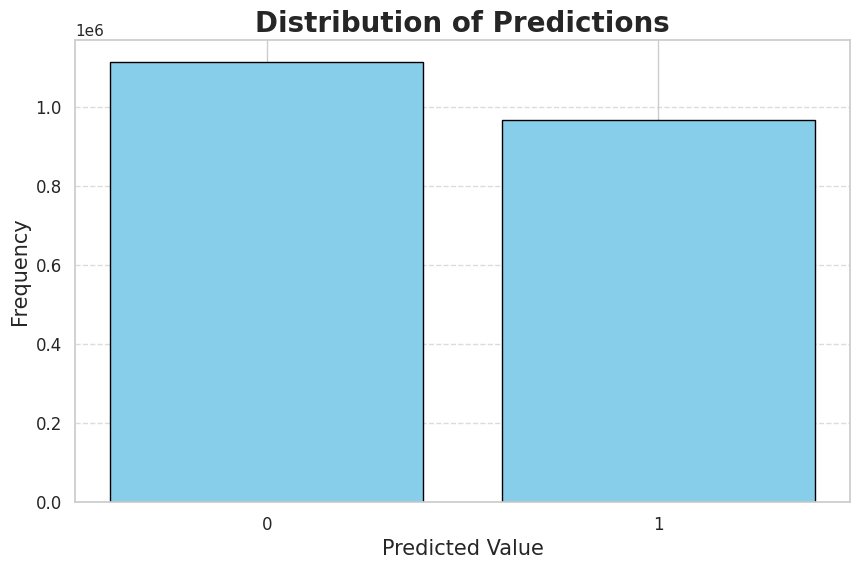

In [347]:
plt.figure(figsize=(10, 6))
plt.hist(test_preds, bins=np.arange(test_preds.min(), test_preds.max() + 2) - 0.5, 
         edgecolor='black', color='skyblue', rwidth=0.8)
plt.title('Distribution of Predictions', fontsize=20, fontweight='bold')
plt.xlabel('Predicted Value', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.xticks(np.arange(test_preds.min(), test_preds.max() + 1), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

submission = pd.DataFrame({
    'id': test_df['id'],
    'class': pd.Series(test_preds).map({0: 'e', 1: 'p'})
})
file = f'mushroom_subm_{type(final_model).__name__}.parquet'
submission.to_parquet('submission', index=False)
submission.to_parquet(file, index=False)
pd.read_parquet(file).head()

# # kaggle submission container expects a csv file
submission.to_csv('submission.csv', index=False)
!head submission.csv

# WARNING DONT COMMIT ME

In [349]:
# !kaggle competitions submit -c playground-series-s4e8 -f submission.parquet -m 'simple net'

In [350]:
import argparse
from kaggle.api.kaggle_api_extended import KaggleApi

def submit_to_kaggle(competition, file, message):
    api = KaggleApi()
    api.authenticate()
    api.competition_submit(file, message, competition)
    print(f"Submitted {file} to {competition} with message: {message}")

submit_to_kaggle(competition, file, str(params))

!sleep 30
!kaggle competitions submissions {competition}

100%|██████████| 8.19M/8.19M [00:00<00:00, 11.7MB/s]


ApiException: (400)
Reason: Bad Request
HTTP response headers: HTTPHeaderDict({'Content-Type': 'application/json', 'Date': 'Mon, 19 Aug 2024 04:28:38 GMT', 'Access-Control-Allow-Credentials': 'true', 'Access-Control-Allow-Origin': '*', 'Set-Cookie': 'ka_sessionid=da1586458a5c40bc088737d2b22dcbd1; max-age=2626560; path=/, GCLB=CNCVhfTSqf31lwEQAw; path=/; HttpOnly', 'Vary': 'Accept-Encoding', 'X-Kaggle-MillisecondsElapsed': '166', 'X-Kaggle-RequestId': 'd47d280454cd498c7731710651948c21', 'X-Kaggle-ApiVersion': '1.6.17', 'X-Kaggle-HubVersion': '0.2.9', 'X-Frame-Options': 'SAMEORIGIN', 'Strict-Transport-Security': 'max-age=63072000; includeSubDomains; preload', 'Content-Security-Policy': "object-src 'none'; script-src 'nonce-dk44qbs/50Yc+hfjz/VlEQ==' 'report-sample' 'unsafe-inline' 'unsafe-eval' 'strict-dynamic' https: http:; base-uri 'none'; report-uri https://csp.withgoogle.com/csp/kaggle/20201130; frame-src 'self' https://www.kaggleusercontent.com https://www.youtube.com/embed/ https://